# 第十二組 食譜評論英文文字分析

以 Food.com 使用者食譜評論（**RAW_interactions.csv**）為資料集，進行完整英文文字分析。

https://www.kaggle.com/datasets/shuyangli94/food-com-recipes-and-user-interactions/data

組員：M144020066龍健銘、M144020028白茗仁、M144020036陳柏勳、M144020065藍立衡

## 動機與目的
食譜社群平台匯聚了大量使用者的烹飪經驗與評論，這些文字資料不僅記錄了食物的口味與製作過程，也反映了使用者的情感表達與社群互動模式。Food.com 作為全球知名的食譜分享平台，
擁有超過 130 萬筆使用者評論，是研究飲食文化與社群行為的豐富語料。
本專案以 Food.com 的食譜評論資料為對象，目的有三：
1. 了解評論的情感傾向：透過 LIWC 情感分析與文件分類模型，
   探討使用者對食譜的正負評價模式，以及評分高低與評論文字之間的關聯。
2. 挖掘評論的潛在主題：運用 LDA 與 BERTopic 兩種主題模型，
   比較傳統詞頻統計與語意嵌入方法在食譜評論主題萃取上的差異，
   觀察使用者評論是否呈現出特定的料理類型或飲食偏好。
3. 分析社群的互動特徵：透過詞彙網路圖，觀察評論中高頻詞彙的共現關係，
   探討食譜社群的語言文化是否以情感互動為主，而非具體的食物描述。

## 資料集描述
本專案使用Kaggle上的Food.com食譜與使用者互動資料集，
資料來源為美國知名食譜社群平台 Food.com，涵蓋 1999 年至 2018 年間的使用者行為紀錄。
- 食譜數量：180K+
- 互動紀錄（評論）數量：700K+
- 時間範圍：1999 – 2018 年
- 資料語言：英文
- 主要使用檔案：`RAW_interactions.csv`（評論、評分）
- 核心分析欄位：`review`（評論文字）、`rating`（1–5 星評分）

## 分析大綱

- 資料前處理
- 情緒分析（LIWC）
- 文本特徵提取（TF-IDF / N-gram）
- 文件分類
- 主題模型（LDA）
- 語意嵌入（Sentence Embeddings）
- 語意主題模型（BERTopic）
- 詞彙網路圖


## 套件載入與資料準備

In [49]:
# 安裝必要套件（第一次執行時取消註解）
#!pip install nltk wordcloud vaderSentiment textblob gensim pyLDAvis seaborn networkx
#!pip install sentence-transformers  # Week 11（較大）
#!pip install bertopic hdbscan       # Week 12（較大）

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import re
import time
import warnings
from collections import Counter
warnings.filterwarnings('ignore')

# NLTK
import nltk
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
from nltk import ngrams, FreqDist

# 視覺化
from wordcloud import WordCloud
import seaborn as sns

# sklearn
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer, TfidfTransformer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn import svm

# NetworkX
import networkx as nx

# 下載 NLTK 資源
for resource in ['punkt', 'punkt_tab', 'stopwords', 'averaged_perceptron_tagger', 'movie_reviews']:
    nltk.download(resource, quiet=True)

plt.rcParams['font.size'] = 12
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.family'] = ['Microsoft YaHei', 'sans-serif']
plt.rcParams['axes.unicode_minus'] = False
%matplotlib inline
print('套件載入完成')

Task was destroyed but it is pending!
task: <Task pending name='Task-205' coro=<_async_in_context.<locals>.run_in_context() done, defined at C:\Users\user\.conda\envs\SMA\Lib\site-packages\ipykernel\utils.py:57> wait_for=<Task pending name='Task-206' coro=<Kernel.shell_main() running at C:\Users\user\.conda\envs\SMA\Lib\site-packages\ipykernel\kernelbase.py:597> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at C:\Users\user\.conda\envs\SMA\Lib\site-packages\zmq\eventloop\zmqstream.py:563]>
Task was destroyed but it is pending!
task: <Task pending name='Task-206' coro=<Kernel.shell_main() running at C:\Users\user\.conda\envs\SMA\Lib\site-packages\ipykernel\kernelbase.py:597> cb=[Task.task_wakeup()]>


套件載入完成


In [51]:
# 載入資料
df = pd.read_csv('RAW_interactions.csv')
print(f'資料集大小: {df.shape}')
print(f'\n欄位: {df.columns.tolist()}')
print(f'\n評分分布:')
print(df['rating'].value_counts().sort_index())
df.head(3)

資料集大小: (1132367, 5)

欄位: ['user_id', 'recipe_id', 'date', 'rating', 'review']

評分分布:
rating
0     60847
1     12818
2     14123
3     40855
4    187360
5    816364
Name: count, dtype: int64


,user_id,recipe_id,date,rating,review
0,38094,40893,2003-02-17,4,Great with a salad. Cooked on top of stove for...
1,1293707,40893,2011-12-21,5,"So simple, so delicious! Great for chilly fall..."
2,8937,44394,2002-12-01,4,This worked very well and is EASY. I used not...


In [52]:
# 過濾空白評論 + 移除 0 星（0 代表未評分，非真實評分）
df = df[df['review'].notna() & (df['review'].str.strip() != '')].copy()
df = df[df['rating'] >= 1].copy()
print(f'有評論的資料筆數（排除0星）: {len(df):,}')

# 取樣本（避免計算量過大）
SAMPLE_SIZE = 10000
df_sample = df.sample(n=SAMPLE_SIZE, random_state=42).reset_index(drop=True)
print(f'\n取樣後: {len(df_sample):,} 筆')
print(f'\n取樣評分分布:')
print(df_sample['rating'].value_counts().sort_index())

有評論的資料筆數（排除0星）: 1,071,348

取樣後: 10,000 筆

取樣評分分布:
rating
1     122
2     129
3     378
4    1748
5    7623
Name: count, dtype: int64


---
## 資料前處理

- 資料清理（去除 HTML、標點符號、數字）
- 斷句與斷詞（Sentence / Word Tokenization）
- 大小寫正規化
- Stemming（PorterStemmer）
- 去除停用字（Stopwords Removal）


In [53]:
# 3.1 資料清理
def clean_text(text):
    text = re.sub(r'<br\s*/?>', ' ', str(text))  # 去除 HTML 換行
    text = re.sub(r'[^\w\s]', '', text)          # 只保留英文字母和空格
    text = re.sub(r'\d+', '', text)               # 去除數字
    text = re.sub(r'\s+', ' ', text).strip()      # 去除多餘空格
    return text.lower()

df_sample['clean_review'] = df_sample['review'].apply(clean_text)

# 3.2 斷詞（Tokenization）
df_sample['tokens'] = df_sample['clean_review'].apply(nltk.word_tokenize)

print('原始評論：')
print(df_sample['review'][0][:150])
print('\n清理後：')
print(df_sample['clean_review'][0][:150])
print('\n斷詞結果：')
print(df_sample['tokens'][0][:15])

原始評論：
My husband came home yesterday with pheasant he had shot and asked me to cook them up.  I had never made pheasant before so this was my first attempt.

清理後：
my husband came home yesterday with pheasant he had shot and asked me to cook them up i had never made pheasant before so this was my first attempt th

斷詞結果：
['my', 'husband', 'came', 'home', 'yesterday', 'with', 'pheasant', 'he', 'had', 'shot', 'and', 'asked', 'me', 'to', 'cook']


In [54]:
# 3.3 大小寫正規化 + Stemming
porter = PorterStemmer()
stop_words = set(stopwords.words('english'))
with open('dict/stopwords.txt', encoding='utf-8') as _f:
    stop_words.update(line.strip() for line in _f if line.strip())
with open('dict/text_stopwords.txt', encoding='utf-8') as _f:
    stop_words.update(line.strip() for line in _f if line.strip())

def stem_tokens(tokens):
    return [porter.stem(t) for t in tokens if t.isalpha()]

def remove_stopwords(tokens):
    return [t for t in tokens if t not in stop_words]

# 3.4 去除停用字
df_sample['stem_tokens'] = df_sample['tokens'].apply(stem_tokens)
df_sample['clean_tokens'] = df_sample['stem_tokens'].apply(remove_stopwords)

print('原始 tokens：  ', df_sample['tokens'][0][:10])
print('Stemming 後：  ', df_sample['stem_tokens'][0][:10])
print('去除停用字後：', df_sample['clean_tokens'][0][:10])
print(f'\n去除停用字前 token 總數: {df_sample["stem_tokens"].apply(len).sum():,}')
print(f'去除停用字後 token 總數: {df_sample["clean_tokens"].apply(len).sum():,}')

原始 tokens：   ['my', 'husband', 'came', 'home', 'yesterday', 'with', 'pheasant', 'he', 'had', 'shot']
Stemming 後：   ['my', 'husband', 'came', 'home', 'yesterday', 'with', 'pheasant', 'he', 'had', 'shot']
去除停用字後： ['husband', 'came', 'home', 'yesterday', 'pheasant', 'shot', 'ask', 'cook', 'never', 'pheasant']

去除停用字前 token 總數: 519,668
去除停用字後 token 總數: 252,901


In [55]:
# 3.5 詞頻分析
all_tokens = [tok for toks in df_sample['clean_tokens'] for tok in toks]
freq_counter = Counter(all_tokens)
freq_df = pd.DataFrame(freq_counter.most_common(10), columns=['word', 'count'])
print('詞頻最高前30個詞：')
freq_df.head(20)

詞頻最高前30個詞：


,word,count
0,recip,6325
1,love,2881
2,great,2777
3,good,2732
4,like,2310
5,time,2302
6,ad,2194
7,realli,1790
8,tast,1729
9,flavor,1704


---
## 情緒分析（LIWC）

使用 LIWC（Linguistic Inquiry and Word Count）情緒字典，對評論進行正向／負向情緒標記，分析不同評分等級的情緒特徵。

In [56]:
# 4.1 載入 LIWC 英文情緒字典
import os
liwc_path = 'week04/dict/liwc/LIWC_EN.csv'

if os.path.exists(liwc_path):
    liwc_dict = pd.read_csv(liwc_path)
    liwc_dict = liwc_dict.rename(columns={'name': 'word', 'class': 'sentiments'})
    print('LIWC 字典載入成功')
    print(f'字典大小: {len(liwc_dict)} 筆')
    print('\n情緒類別分布：')
    print(liwc_dict['sentiments'].value_counts())
else:
    print(f'找不到 {liwc_path}，改用內建正負詞列表')
    # 使用簡易替代字典
    pos_words = ['good','great','excellent','wonderful','love','loved','amazing','delicious',
                 'perfect','fantastic','best','fresh','tender','flavorful','crispy','creamy']
    neg_words = ['bad','terrible','awful','horrible','poor','worst','bland','soggy','greasy',
                 'tough','dry','burnt','salty','bitter','hard','fail']
    liwc_dict = pd.concat([
        pd.DataFrame({'word': pos_words, 'sentiments': 'positive'}),
        pd.DataFrame({'word': neg_words, 'sentiments': 'negative'})
    ]).reset_index(drop=True)
    print('已使用簡易替代字典')
    print(f'字典大小: {len(liwc_dict)} 筆')

liwc_dict.head(10)

找不到 week04/dict/liwc/LIWC_EN.csv，改用內建正負詞列表
已使用簡易替代字典
字典大小: 32 筆


,word,sentiments
0,good,positive
1,great,positive
2,excellent,positive
3,wonderful,positive
4,love,positive
5,loved,positive
6,amazing,positive
7,delicious,positive
8,perfect,positive
9,fantastic,positive


In [57]:
# 4.2 將 token 展開成長格式，與 LIWC 合併
token_df = df_sample[['user_id', 'recipe_id', 'rating', 'clean_tokens']].copy()
token_df = token_df.explode('clean_tokens').rename(columns={'clean_tokens': 'word'})
token_df = token_df.dropna(subset=['word'])
token_df = token_df[token_df['word'].str.strip() != '']

print(f'Token 展開後總筆數: {len(token_df):,}')

# 與 LIWC 合併
liwc_merged = pd.merge(token_df, liwc_dict, on='word', how='left')
print(f'有情緒標記的 Token 數: {liwc_merged["sentiments"].notna().sum():,}')
liwc_merged.head(5)

Token 展開後總筆數: 252,901
有情緒標記的 Token 數: 11,155


,user_id,recipe_id,rating,word,sentiments
0,857024,46193,5,husband,NaN
1,857024,46193,5,came,NaN
2,857024,46193,5,home,NaN
3,857024,46193,5,yesterday,NaN
4,857024,46193,5,pheasant,NaN


In [58]:
# 4.3 各評分等級的正負向情緒詞數量
mask = liwc_merged['sentiments'].isin(['positive', 'negative'])
sentiment_by_rating = (
    liwc_merged[mask]
    .groupby(['rating', 'sentiments'])
    .size()
    .reset_index(name='count')
)

# 計算各評分下正/負向情緒的比例
sentiment_by_rating['total'] = sentiment_by_rating.groupby('rating')['count'].transform('sum')
sentiment_by_rating['ratio'] = sentiment_by_rating['count'] / sentiment_by_rating['total']

print('各評分等級的情緒詞數量：')
sentiment_by_rating

各評分等級的情緒詞數量：


,rating,sentiments,count,total,ratio
0,1,negative,27,58,0.465517
1,1,positive,31,58,0.534483
2,2,negative,39,92,0.423913
3,2,positive,53,92,0.576087
4,3,negative,63,330,0.190909
5,3,positive,267,330,0.809091
6,4,negative,121,2025,0.059753
7,4,positive,1904,2025,0.940247
8,5,negative,204,8650,0.023584
9,5,positive,8446,8650,0.976416


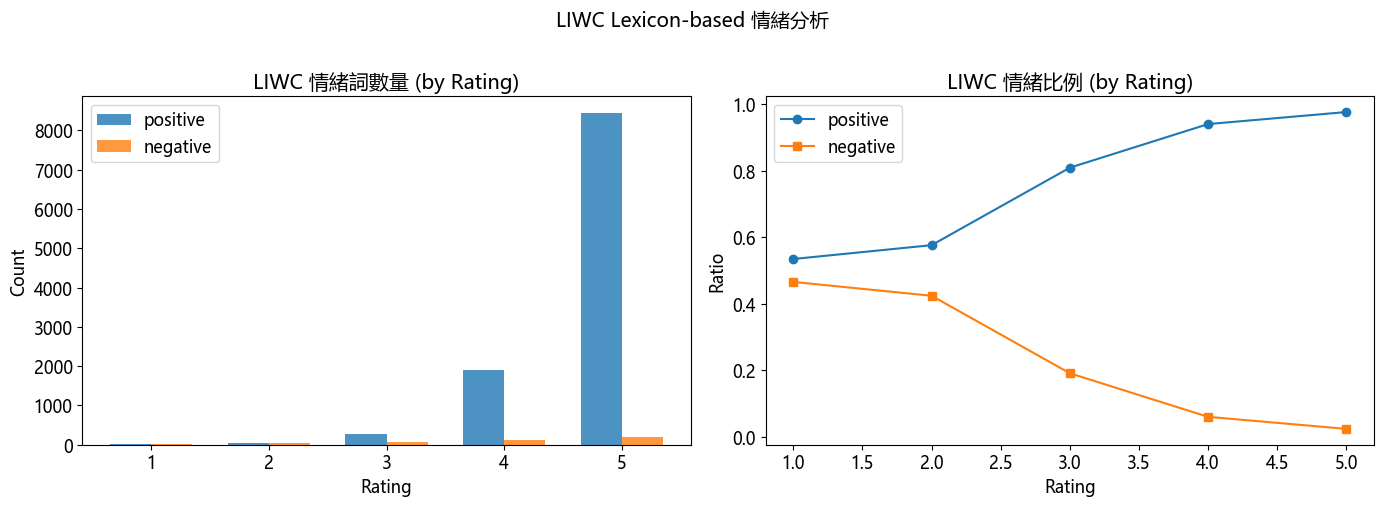

In [59]:
# 4.4 情緒視覺化
pos = sentiment_by_rating[sentiment_by_rating['sentiments'] == 'positive'].sort_values('rating')
neg = sentiment_by_rating[sentiment_by_rating['sentiments'] == 'negative'].sort_values('rating')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 情緒詞聲量長條圖
ratings = sorted(sentiment_by_rating['rating'].unique())
x = np.arange(len(ratings))
w = 0.35
axes[0].bar(x - w/2, pos.set_index('rating').reindex(ratings)['count'].fillna(0),
            w, label='positive', color='tab:blue', alpha=0.8)
axes[0].bar(x + w/2, neg.set_index('rating').reindex(ratings)['count'].fillna(0),
            w, label='negative', color='tab:orange', alpha=0.8)
axes[0].set_xticks(x)
axes[0].set_xticklabels(ratings)
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Count')
axes[0].set_title('LIWC 情緒詞數量 (by Rating)')
axes[0].legend()

# 情緒比例折線圖
axes[1].plot(pos['rating'], pos['ratio'], 'o-', label='positive', color='tab:blue')
axes[1].plot(neg['rating'], neg['ratio'], 's-', label='negative', color='tab:orange')
axes[1].set_xlabel('Rating')
axes[1].set_ylabel('Ratio')
axes[1].set_title('LIWC 情緒比例 (by Rating)')
axes[1].legend()

plt.suptitle('LIWC Lexicon-based 情緒分析', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

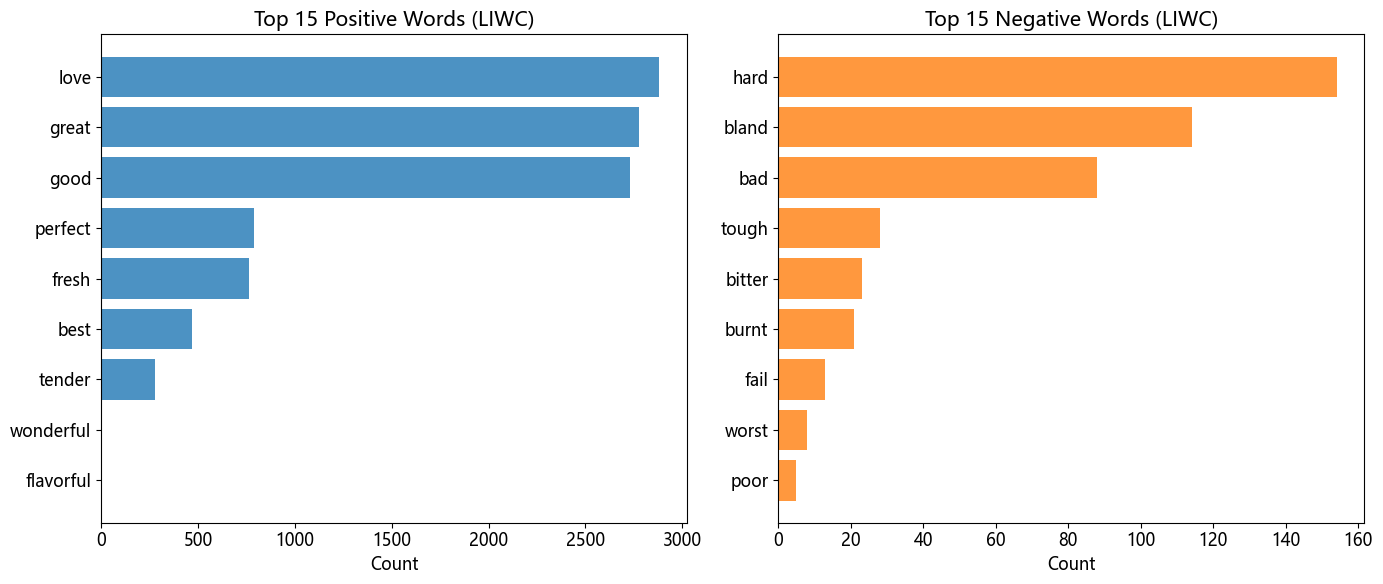

In [60]:
# 4.5 正負向情緒代表字
word_count = (
    liwc_merged[liwc_merged['sentiments'].isin(['positive', 'negative'])]
    .groupby(['word', 'sentiments'])
    .size()
    .reset_index(name='count')
)

top_pos = word_count[word_count['sentiments'] == 'positive'].nlargest(15, 'count')
top_neg = word_count[word_count['sentiments'] == 'negative'].nlargest(15, 'count')

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].barh(top_pos.sort_values('count')['word'], top_pos.sort_values('count')['count'],
             color='tab:blue', alpha=0.8)
axes[0].set_title('Top 15 Positive Words (LIWC)')
axes[0].set_xlabel('Count')

axes[1].barh(top_neg.sort_values('count')['word'], top_neg.sort_values('count')['count'],
             color='tab:orange', alpha=0.8)
axes[1].set_title('Top 15 Negative Words (LIWC)')
axes[1].set_xlabel('Count')

plt.tight_layout()
plt.show()

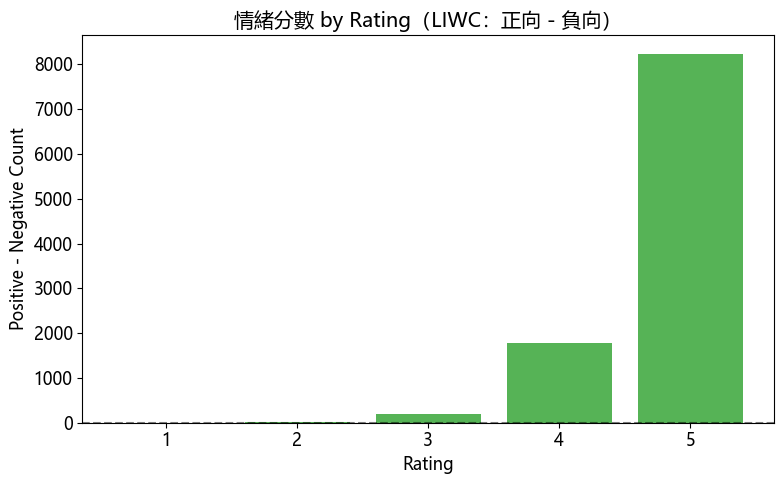

In [61]:
# 4.6 各評分等級的情緒分數（positive - negative）
sentiment_value = sentiment_by_rating.pivot_table(
    index='rating', columns='sentiments', values='count', fill_value=0
).reset_index()

if 'positive' in sentiment_value.columns and 'negative' in sentiment_value.columns:
    sentiment_value['sentiment_score'] = sentiment_value['positive'] - sentiment_value['negative']
    
    fig, ax = plt.subplots(figsize=(8, 5))
    colors = ['tab:red' if s < 0 else 'tab:green' for s in sentiment_value['sentiment_score']]
    ax.bar(sentiment_value['rating'], sentiment_value['sentiment_score'], color=colors, alpha=0.8)
    ax.axhline(y=0, color='black', linestyle='--', alpha=0.5)
    ax.set_xlabel('Rating')
    ax.set_ylabel('Positive - Negative Count')
    ax.set_title('情緒分數 by Rating（LIWC：正向 - 負向）')
    plt.tight_layout()
    plt.show()

---
## 文本特徵提取（TF-IDF / N-gram）

- **DTM**（Document Term Matrix）：以詞頻表示文件
- **TF-IDF**：詞頻-逆文件頻率，識別各文件中的關鍵詞
- **N-gram**：Bigram / Trigram，尋找常見的詞彙組合
- **Pairwise Correlation**：計算詞彙間的 Pearson 相關係數
- **Cosine Similarity**：計算文件間的向量相似度


In [62]:
# 6.1 建立文件詞彙矩陣（DTM）
# 以每筆評論為單位，將 clean_tokens 轉為以空格連接的字串
df_sample['tokens_str'] = df_sample['clean_tokens'].apply(lambda x: ' '.join(x))
df_tfidf = df_sample[df_sample['tokens_str'].str.strip() != ''].copy()

# Bag of Words（CountVectorizer）
vectorizer = CountVectorizer(max_features=500, min_df=5)
X_bow = vectorizer.fit_transform(df_tfidf['tokens_str'])
vocab = vectorizer.get_feature_names_out()

import math
DTM_df = pd.DataFrame(X_bow.toarray(), columns=vocab)
print(f'DTM 維度: {DTM_df.shape}')
print(f'範例（前5欄）：')
DTM_df.head(3).iloc[:, :5]

DTM 維度: (9999, 500)
範例（前5欄）：


,absolut,actual,ad,add,addit
0,0,0,0,0,0
1,0,0,0,0,0
2,0,0,0,1,0


In [63]:
# 6.2 TF-IDF 計算（使用套件）
transformer = TfidfTransformer()
X_tfidf = transformer.fit_transform(X_bow)
TFIDF_df = pd.DataFrame(X_tfidf.toarray(), columns=vocab)

# 方法1：各詞彙的平均 TF-IDF 值（整體關鍵詞）
avg_tfidf = TFIDF_df.mean().sort_values(ascending=False)
print('整體 TF-IDF 平均值最高前15詞：')
print(avg_tfidf.head(10).to_string())

整體 TF-IDF 平均值最高前15詞：
recip     0.061456
love      0.042934
good      0.042051
great     0.040963
like      0.031984
delici    0.029850
time      0.029609
ad        0.028792
realli    0.028245
tast      0.026411


In [64]:
# 6.3 方法2：各文件 TF-IDF 最高前10詞 → 統計出現頻率
tfidf_long = TFIDF_df.copy()
tfidf_long['doc_id'] = range(len(tfidf_long))
tfidf_long = tfidf_long.melt(id_vars='doc_id', var_name='word', value_name='tfidf')

top_word_freq = (
    tfidf_long.groupby('doc_id')
    .apply(lambda x: x.nlargest(10, 'tfidf'), include_groups=False)
    .reset_index(drop=True)
    .groupby('word', as_index=False)
    .size()
    .sort_values('size', ascending=False)
)

print('在各文件中 TF-IDF 最高前10詞裡出現次數最多的詞：')
top_word_freq.head(10)

在各文件中 TF-IDF 最高前10詞裡出現次數最多的詞：


,word,size
0,absolut,2833
1,actual,2372
2,ad,2290
3,add,1742
4,addit,1310
354,recip,1246
5,agre,896
191,good,837
258,love,827
194,great,822


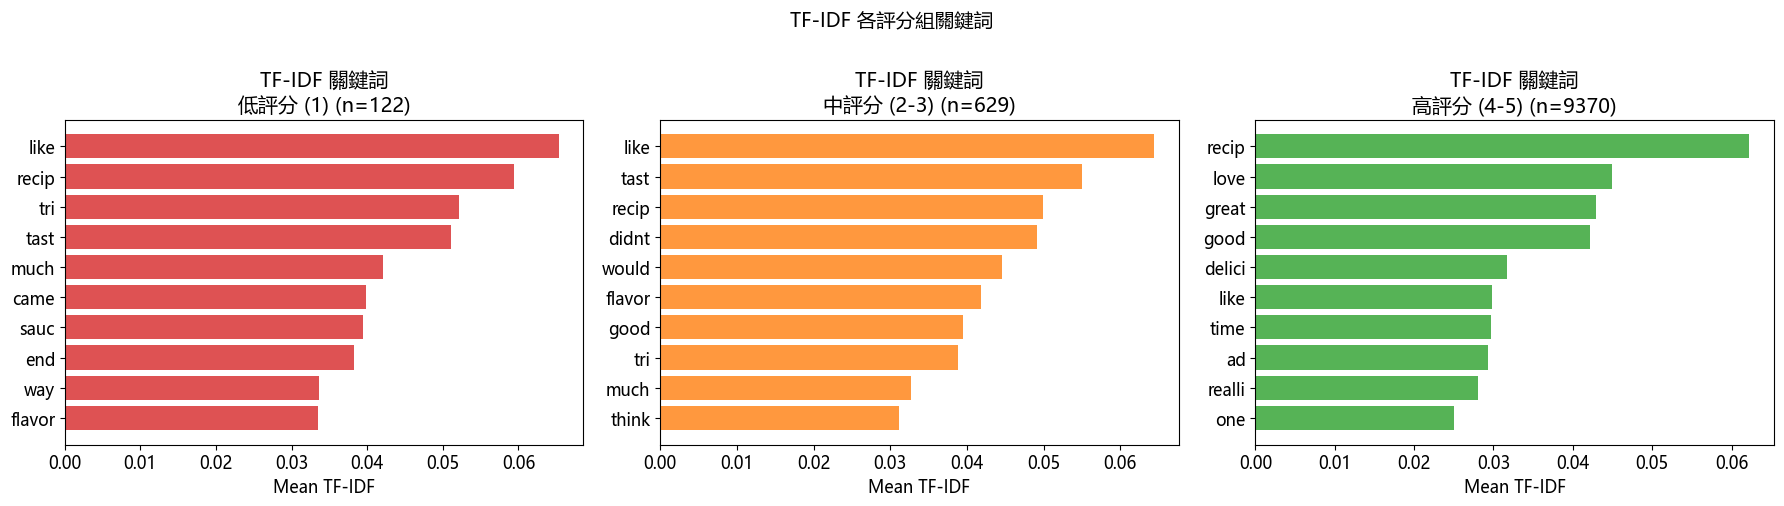

In [65]:
# TF-IDF 關鍵詞 by 評分組
df_tfidf_plot = TFIDF_df.copy()
df_tfidf_plot['rating'] = df_tfidf['rating'].values

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
groups = [('低評分 (1)', df_tfidf_plot[df_tfidf_plot['rating'] <= 1], 'tab:red'),
          ('中評分 (2-3)', df_tfidf_plot[df_tfidf_plot['rating'] <= 3], 'tab:orange'),
          ('高評分 (4-5)', df_tfidf_plot[df_tfidf_plot['rating'] >= 4], 'tab:green')]

for ax, (label, gdf, color) in zip(axes, groups):
    if len(gdf) == 0:
        continue
    top = gdf[vocab].mean().sort_values(ascending=False).head(10)
    ax.barh(top.index[::-1], top.values[::-1], color=color, alpha=0.8)
    ax.set_title(f'TF-IDF 關鍵詞\n{label} (n={len(gdf)})')
    ax.set_xlabel('Mean TF-IDF')

plt.suptitle('TF-IDF 各評分組關鍵詞', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [66]:
# 6.4 N-gram 分析：Bigram
stop_words_ext = set(stopwords.words('english'))
stop_words_ext.update(['would', 'could', 'made', 'make', 'also', 'used', 'use', 'got'])

def get_bigrams(text):
    tokens = nltk.word_tokenize(str(text).lower())
    tokens = [porter.stem(t) for t in tokens
              if t.isalpha() and t not in stop_words_ext and len(t) > 1]
    return list(ngrams(tokens, 2))

all_bigrams = []
for review in df_sample['review']:
    all_bigrams.extend(get_bigrams(review))

bigram_freq = FreqDist(all_bigrams)
top_bigrams = bigram_freq.most_common(20)
bigram_df = pd.DataFrame(
    [(f'{b[0]} {b[1]}', c) for b, c in top_bigrams],
    columns=['bigram', 'count']
)
print('最常出現的 Bigram：')
bigram_df.head(15)

最常出現的 Bigram：


,bigram,count
0,next time,958
1,thank share,734
2,thank post,712
3,great recip,495
4,thank much,396
5,follow recip,285
6,realli good,277
7,share recip,214
8,sour cream,214
9,thank great,206


In [67]:
# 6.5 Trigram 分析
def get_trigrams(text):
    tokens = nltk.word_tokenize(str(text).lower())
    tokens = [porter.stem(t) for t in tokens
              if t.isalpha() and t not in stop_words_ext and len(t) > 1]
    return list(ngrams(tokens, 3))

all_trigrams = []
for review in df_sample['review']:
    all_trigrams.extend(get_trigrams(review))

trigram_freq = FreqDist(all_trigrams)
top_trigrams = trigram_freq.most_common(15)
trigram_df = pd.DataFrame(
    [(f'{t[0]} {t[1]} {t[2]}', c) for t, c in top_trigrams],
    columns=['trigram', 'count']
)
print('最常出現的 Trigram：')
trigram_df

最常出現的 Trigram：


,trigram,count
0,thank share recip,156
1,thank great recip,134
2,thank much share,116
3,follow recip exactli,103
4,thank much post,80
5,red pepper flake,69
6,thank post recip,69
7,think next time,68
8,next time add,55
9,cut recip half,53


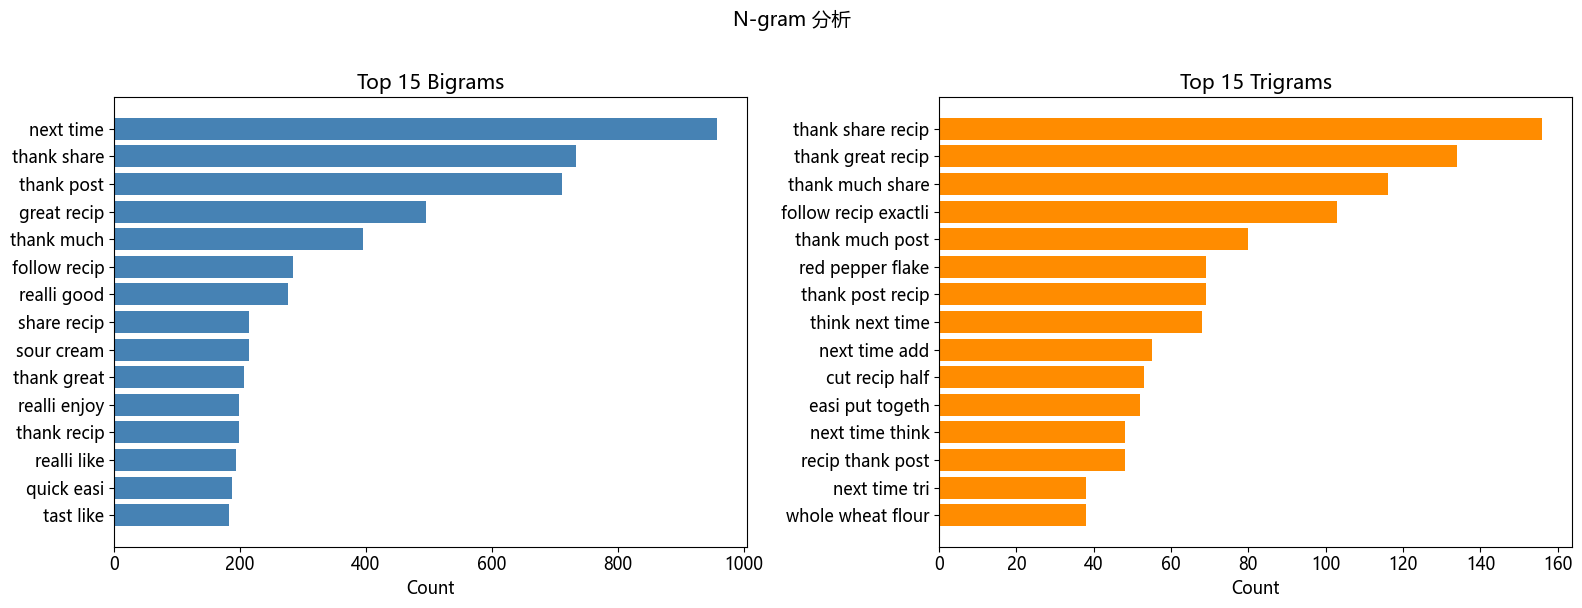

In [68]:
# N-gram 視覺化
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].barh(bigram_df['bigram'][:15][::-1], bigram_df['count'][:15][::-1], color='steelblue')
axes[0].set_xlabel('Count')
axes[0].set_title('Top 15 Bigrams')

axes[1].barh(trigram_df['trigram'][::-1], trigram_df['count'][::-1], color='darkorange')
axes[1].set_xlabel('Count')
axes[1].set_title('Top 15 Trigrams')

plt.suptitle('N-gram 分析', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [69]:
# 6.6 詞彙相關性（Pairwise Pearson Correlation）
vec_cor = CountVectorizer(min_df=10, max_features=100)
X_cor = vec_cor.fit_transform(df_tfidf['tokens_str'])
vocab_cor = vec_cor.get_feature_names_out()

# 計算詞彙間的 Pearson 相關係數
corr_matrix = np.corrcoef(X_cor.toarray().T)
Cor_df = pd.DataFrame(corr_matrix, index=vocab_cor, columns=vocab_cor)

# 展開成長格式，找相關性最高的詞對
Cor_long = Cor_df.stack().reset_index()
Cor_long.columns = ['word1', 'word2', 'cor']
Cor_long = Cor_long[Cor_long['word1'] != Cor_long['word2']]

print('相關性最高的詞對：')
print(Cor_long.sort_values('cor', ascending=False).head(10).to_string(index=False))

相關性最高的詞對：
word1 word2      cor
 next  time 0.563138
 time  next 0.563138
minut  bake 0.257513
 bake minut 0.257513
didnt   ani 0.242169
  ani didnt 0.242169
  ill  next 0.240639
 next   ill 0.240639
  cup sugar 0.234935
sugar   cup 0.234935


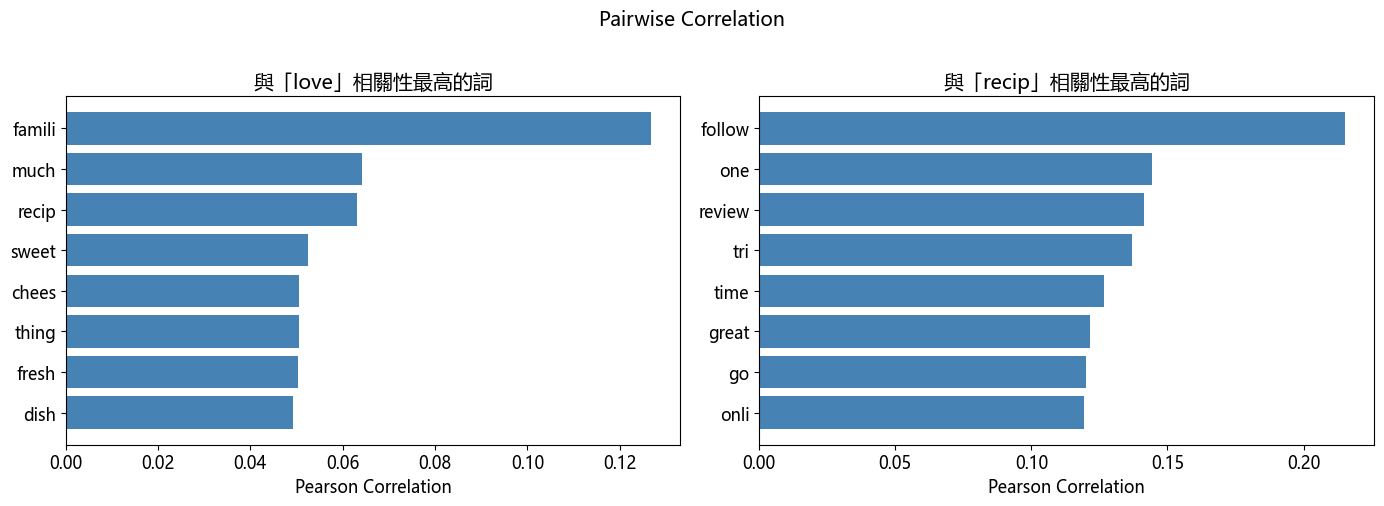

In [70]:
# 與特定詞彙相關性最高的8個詞
focus_words = ['love', 'recip']
fig, axes = plt.subplots(1, len(focus_words), figsize=(14, 5))

for ax, fw in zip(axes, focus_words):
    if fw not in Cor_df.columns:
        ax.text(0.5, 0.5, f'詞彙 "{fw}" 不在字典中', ha='center')
        continue
    top8 = Cor_df[fw].drop(fw).sort_values(ascending=False).head(8).sort_values()
    ax.barh(top8.index, top8.values, color='steelblue')
    ax.set_title(f'與「{fw}」相關性最高的詞')
    ax.set_xlabel('Pearson Correlation')

plt.suptitle('Pairwise Correlation', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

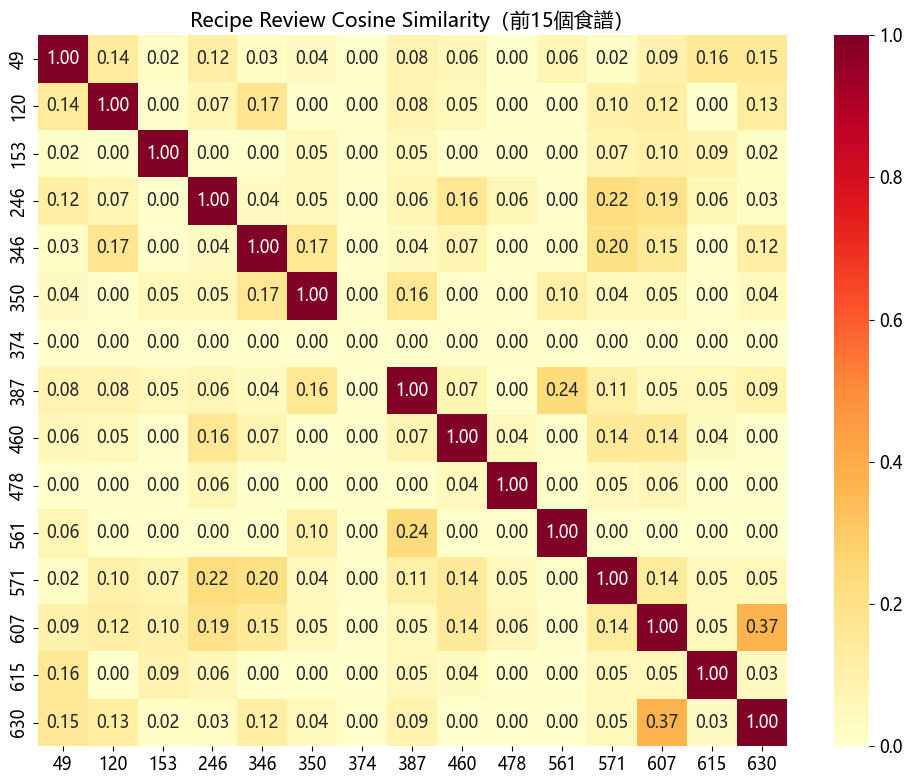

In [71]:
# 6.7 Cosine Similarity（文件相似度）
# 以每個 recipe_id 的合併評論為文件
recipe_reviews = (
    df_sample.groupby('recipe_id')['tokens_str']
    .apply(lambda x: ' '.join(x))
    .reset_index()
)
recipe_reviews = recipe_reviews[recipe_reviews['tokens_str'].str.strip() != '']

vec_cos = CountVectorizer(max_features=300)
X_recipe = vec_cos.fit_transform(recipe_reviews['tokens_str'])
tf_recipe = TfidfTransformer().fit_transform(X_recipe)

# 取前15個食譜計算相似度
n = min(15, len(recipe_reviews))
cos_matrix = cosine_similarity(tf_recipe[:n], tf_recipe[:n])
cos_labels = [str(r)[:6] for r in recipe_reviews['recipe_id'][:n].values]

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cos_matrix, annot=True, fmt='.2f', cmap='YlOrRd',
            xticklabels=cos_labels, yticklabels=cos_labels, ax=ax)
ax.set_title('Recipe Review Cosine Similarity（前15個食譜）')
plt.tight_layout()
plt.show()

---
## 文件分類

以評分作為分類標籤，比較多種分類模型的效果：
- Logistic Regression
- Decision Tree
- SVM
- Random Forest

評估指標：Precision、Recall、F1-score、混淆矩陣

In [72]:
# 7.1 建立二元分類標籤
# 高評分 (4-5) → positive，低評分 (0-2) → negative，排除中立評分 (3)
df_cls = df_sample[df_sample['rating'].isin([0, 1, 2, 4, 5])].copy()
df_cls['label'] = df_cls['rating'].apply(lambda r: 'positive' if r >= 4 else 'negative')

print('分類標籤分布：')
print(df_cls['label'].value_counts())
print(f'\n總筆數: {len(df_cls):,}')

分類標籤分布：
label
positive    9371
negative     251
Name: count, dtype: int64

總筆數: 9,622


In [73]:
# 7.2 Train/Test Split（7:3）
X_cls = df_cls['clean_review']
y_cls = df_cls['label']

X_train, X_test, y_train, y_test = train_test_split(
    X_cls, y_cls, test_size=0.3, random_state=777, stratify=y_cls
)
print(f'訓練集: {len(X_train):,} 筆，測試集: {len(X_test):,} 筆')
print(f'\n訓練集標籤比例：')
print(y_train.value_counts(normalize=True).round(3))

訓練集: 6,735 筆，測試集: 2,887 筆

訓練集標籤比例：
label
positive    0.974
negative    0.026
Name: proportion, dtype: float64


In [74]:
# 7.3 多模型比較
def train_and_evaluate(vec, clf, X_tr, X_te, y_tr, y_te, name):
    v = vec
    v_tr = v.fit_transform(X_tr)
    v_te = v.transform(X_te)
    clf.fit(v_tr, y_tr)
    y_pred = clf.predict(v_te)
    report = classification_report(y_te, y_pred, output_dict=True)
    print(f'\n{"="*55}')
    print(f'模型: {name}')
    print(classification_report(y_te, y_pred))
    return clf, v, report

models = {
    'Logistic Regression': LogisticRegression(max_iter=500, random_state=42),
    'Decision Tree':       DecisionTreeClassifier(max_depth=10, random_state=42),
    'SVM':                 svm.SVC(probability=True, kernel='linear', random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42)
}

results_cls = {}
trained_models_cls = {}

for name, clf in models.items():
    vec = CountVectorizer(max_features=2000, stop_words='english')
    trained_clf, trained_vec, report = train_and_evaluate(
        vec, clf, X_train, X_test, y_train, y_test, name
    )
    results_cls[name] = report
    trained_models_cls[name] = (trained_clf, trained_vec)


模型: Logistic Regression
              precision    recall  f1-score   support

    negative       0.75      0.28      0.41        75
    positive       0.98      1.00      0.99      2812

    accuracy                           0.98      2887
   macro avg       0.87      0.64      0.70      2887
weighted avg       0.98      0.98      0.97      2887


模型: Decision Tree
              precision    recall  f1-score   support

    negative       0.39      0.15      0.21        75
    positive       0.98      0.99      0.99      2812

    accuracy                           0.97      2887
   macro avg       0.69      0.57      0.60      2887
weighted avg       0.96      0.97      0.97      2887


模型: SVM
              precision    recall  f1-score   support

    negative       0.42      0.36      0.39        75
    positive       0.98      0.99      0.98      2812

    accuracy                           0.97      2887
   macro avg       0.70      0.67      0.69      2887
weighted avg       0.

In [75]:
# 7.4 選出最佳模型並繪製混淆矩陣
best_model_name = max(
    results_cls,
    key=lambda k: results_cls[k]['weighted avg']['f1-score']
)
best_f1 = results_cls[best_model_name]['weighted avg']['f1-score']
print(f'最佳模型: {best_model_name}  (F1 = {best_f1:.4f})')

best_clf, best_vec = trained_models_cls[best_model_name]
y_pred_best = best_clf.predict(best_vec.transform(X_test))

# 比較所有模型的 F1-score
f1_compare = pd.DataFrame({
    '模型': list(results_cls.keys()),
    'F1-score (weighted)': [results_cls[k]['weighted avg']['f1-score'] for k in results_cls]
}).sort_values('F1-score (weighted)', ascending=False)
print('\n模型 F1-score 比較：')
print(f1_compare.to_string(index=False))

最佳模型: Logistic Regression  (F1 = 0.9741)

模型 F1-score 比較：
                 模型  F1-score (weighted)
Logistic Regression             0.974138
                SVM             0.969174
      Decision Tree             0.965658
      Random Forest             0.964303


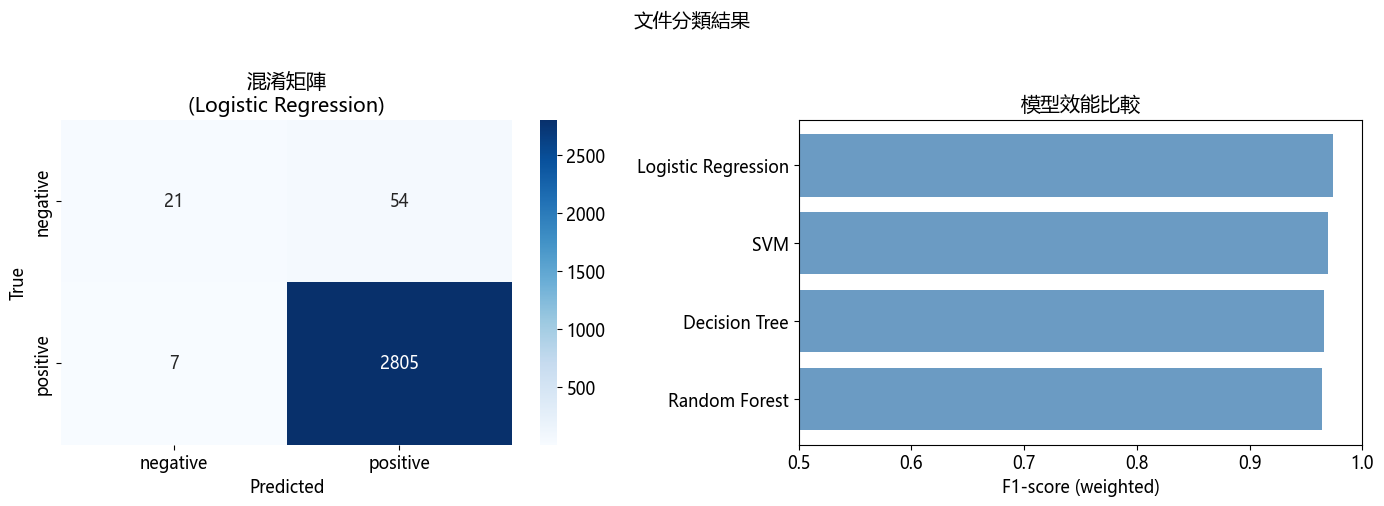

In [76]:
# 混淆矩陣
classes = best_clf.classes_
cm = confusion_matrix(y_test, y_pred_best, labels=classes)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm, annot=True, fmt='d', ax=axes[0], cmap=plt.cm.Blues,
            xticklabels=classes, yticklabels=classes)
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')
axes[0].set_title(f'混淆矩陣\n({best_model_name})')

axes[1].barh(f1_compare['模型'][::-1],
             f1_compare['F1-score (weighted)'][::-1],
             color='steelblue', alpha=0.8)
axes[1].set_xlabel('F1-score (weighted)')
axes[1].set_title('模型效能比較')
axes[1].set_xlim([0.5, 1.0])

plt.suptitle('文件分類結果', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

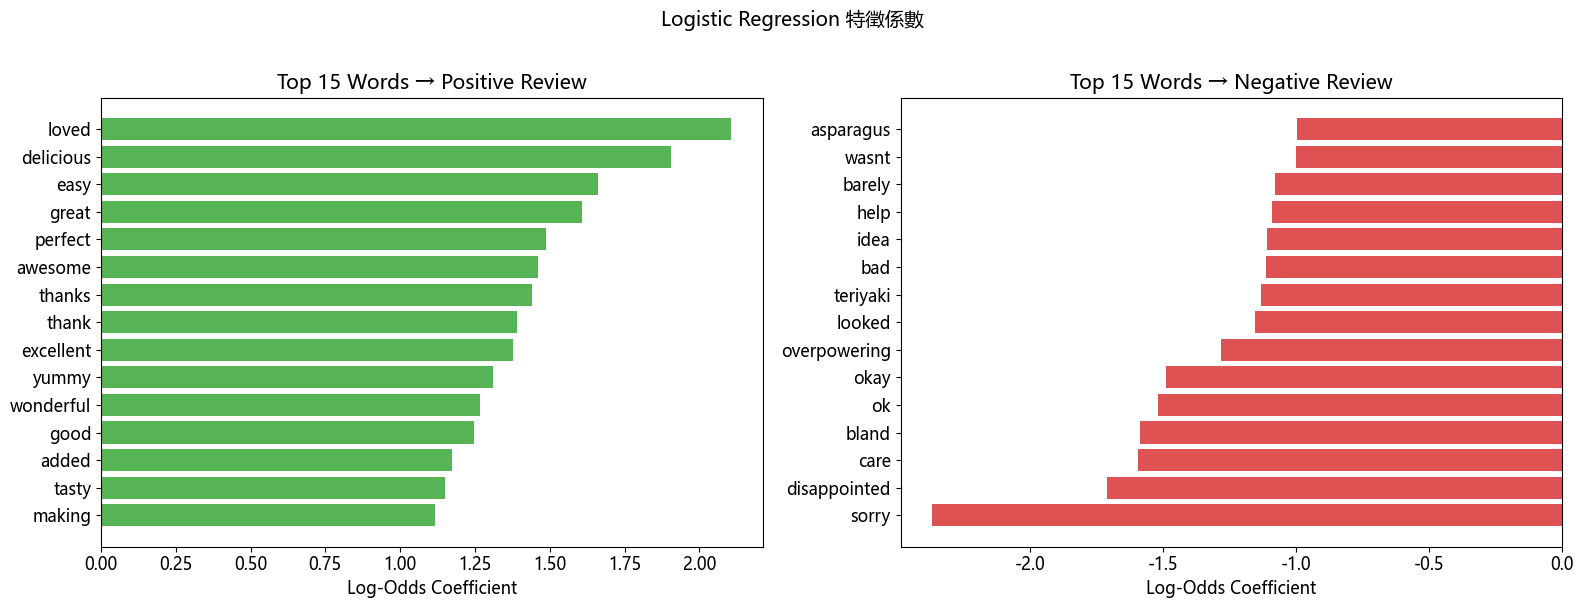

In [77]:
# 7.5 Logistic Regression 特徵重要性（回歸係數分析）
lr_clf, lr_vec = trained_models_cls['Logistic Regression']
feature_names = lr_vec.get_feature_names_out()
coef = lr_clf.coef_[0]

top_n = 15
top_pos_idx = coef.argsort()[-top_n:][::-1]
top_neg_idx = coef.argsort()[:top_n]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].barh(feature_names[top_pos_idx][::-1], coef[top_pos_idx][::-1],
             color='tab:green', alpha=0.8)
axes[0].set_title(f'Top {top_n} Words → Positive Review')
axes[0].set_xlabel('Log-Odds Coefficient')

axes[1].barh(feature_names[top_neg_idx], coef[top_neg_idx],
             color='tab:red', alpha=0.8)
axes[1].set_title(f'Top {top_n} Words → Negative Review')
axes[1].set_xlabel('Log-Odds Coefficient')

plt.suptitle('Logistic Regression 特徵係數', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

---
## 主題模型（LDA）

- **LDA**（Latent Dirichlet Allocation）：非監督式學習，自動從文本中萃取主題
- 使用 **Perplexity** 和 **PMI Coherence** 評估主題品質
- 使用 **pyLDAvis** 互動式視覺化

In [78]:
try:
    from gensim.models import Phrases, LdaModel, CoherenceModel
    from gensim.corpora import Dictionary
    from gensim.matutils import corpus2csc
    gensim_available = True
except ImportError:
    print('請安裝 gensim: pip install gensim')
    gensim_available = False

if gensim_available:
    # 取樣 5000 筆評論
    LDA_SAMPLE = min(5000, len(df_sample))
    df_lda = df_sample.sample(n=LDA_SAMPLE, random_state=42).reset_index(drop=True)
    
    # 使用已清理好的 token 列表（過濾太短的評論）
    docs_lda = df_lda['clean_tokens'].tolist()
    docs_lda = [d for d in docs_lda if len(d) >= 5]
    
    print(f'LDA 訓練文件數: {len(docs_lda):,}')
    print(f'範例 doc[0]: {docs_lda[0][:10]}')

LDA 訓練文件數: 4,788
範例 doc[0]: ['thought', 'quit', 'tasti', 'serv', 'corn', 'cob', 'salad', 'avocado', 'jicima', 'tomato']


In [79]:
if gensim_available:
    # 找出常見的 Bigram 並加入詞彙表
    bigram_model_lda = Phrases(docs_lda, min_count=20)
    for idx in range(len(docs_lda)):
        for token in bigram_model_lda[docs_lda[idx]]:
            if '_' in token:
                docs_lda[idx].append(token)
    
    # 建立字典與 Corpus
    dictionary = Dictionary(docs_lda)
    dictionary.filter_extremes(no_below=5, no_above=0.5)  # 過濾極端詞
    corpus = [dictionary.doc2bow(doc) for doc in docs_lda]
    
    print(f'字典大小: {len(dictionary):,} 個詞')
    print(f'Corpus 大小: {len(corpus):,} 篇文件')

字典大小: 2,130 個詞
Corpus 大小: 4,788 篇文件


In [80]:
if gensim_available:
    # 訓練不同主題數的 LDA 模型，評估最佳主題數
    t0 = time.time()
    topic_num_list = list(range(2, 9))
    result_lda = {'topic_num': [], 'perplexity': [], 'pmi': []}
    model_set_lda = {}
    
    for topic_num in topic_num_list:
        m = LdaModel(
            corpus=corpus,
            num_topics=topic_num,
            id2word=dictionary,
            random_state=42,
            passes=5
        )
        loss = m.log_perplexity(corpus)
        perplexity = np.exp(-1. * loss)
        try:
            pmi = CoherenceModel(model=m, texts=docs_lda, coherence='c_npmi').get_coherence()
        except:
            pmi = 0
        result_lda['topic_num'].append(topic_num)
        result_lda['perplexity'].append(perplexity)
        result_lda['pmi'].append(pmi)
        model_set_lda[topic_num] = m
        print(f'  Topic {topic_num}: perplexity={perplexity:.1f}, pmi={pmi:.4f}')
    
    result_lda = pd.DataFrame(result_lda)
    print(f'\n訓練完成，耗時 {time.time()-t0:.1f} 秒')
    result_lda

  Topic 2: perplexity=819.5, pmi=-0.0140
  Topic 3: perplexity=848.5, pmi=-0.0122
  Topic 4: perplexity=871.6, pmi=-0.0072
  Topic 5: perplexity=886.9, pmi=-0.0024
  Topic 6: perplexity=898.2, pmi=0.0044
  Topic 7: perplexity=922.6, pmi=0.0043
  Topic 8: perplexity=941.9, pmi=-0.0032

訓練完成，耗時 123.2 秒


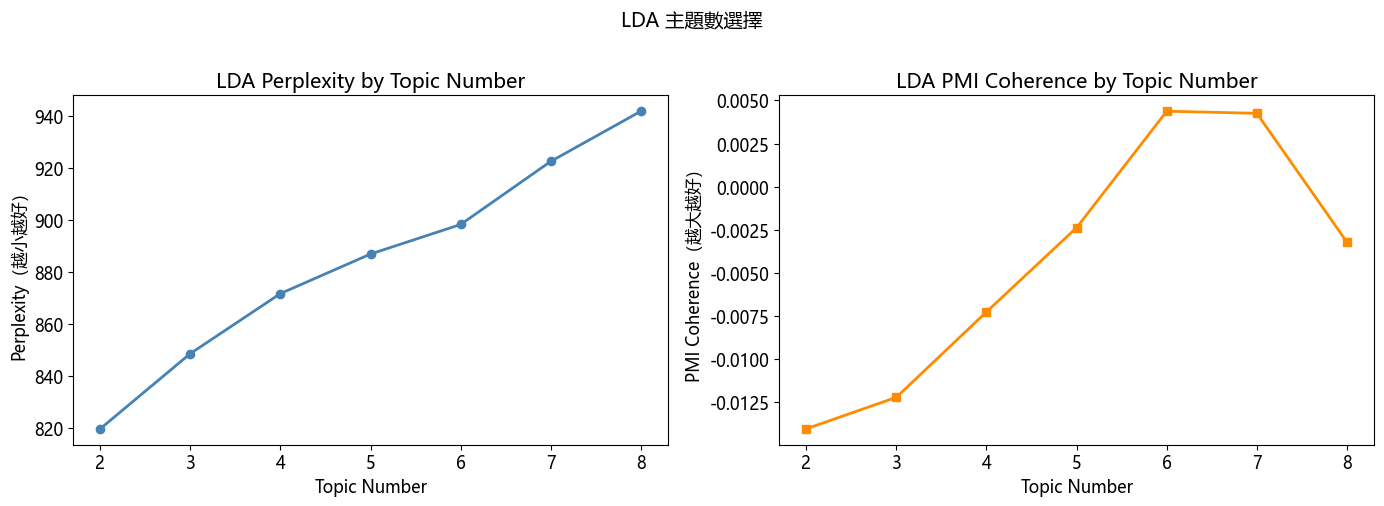

In [81]:
if gensim_available:
    # 視覺化 Perplexity 和 PMI
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    axes[0].plot(result_lda['topic_num'], result_lda['perplexity'], 'o-', color='steelblue', lw=2)
    axes[0].set_xlabel('Topic Number')
    axes[0].set_ylabel('Perplexity（越小越好）')
    axes[0].set_title('LDA Perplexity by Topic Number')
    
    axes[1].plot(result_lda['topic_num'], result_lda['pmi'], 's-', color='darkorange', lw=2)
    axes[1].set_xlabel('Topic Number')
    axes[1].set_ylabel('PMI Coherence（越大越好）')
    axes[1].set_title('LDA PMI Coherence by Topic Number')
    
    plt.suptitle('LDA 主題數選擇', fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()

In [82]:
if gensim_available:
    # 選用主題數
    BEST_TOPIC_NUM = 6
    best_lda = model_set_lda[BEST_TOPIC_NUM]
    
    print(f'主題數 = {BEST_TOPIC_NUM} 的主題詞分布：\n')
    for i in range(BEST_TOPIC_NUM):
        top_words = best_lda.show_topic(i, topn=10)
        word_str = ', '.join([f'{w}({p:.3f})' for w, p in top_words])
        print(f'Topic {i+1}: {word_str}')

主題數 = 6 的主題詞分布：

Topic 1: cake(0.023), sugar(0.022), cup(0.021), cream(0.021), chocol(0.012), recip(0.011), good(0.011), milk(0.010), ice(0.010), like(0.009)
Topic 2: recip(0.038), dish(0.022), great(0.016), potato(0.016), love(0.015), delici(0.014), realli(0.014), flavor(0.014), chicken(0.014), follow(0.012)
Topic 3: recip(0.044), love(0.017), great(0.016), cooki(0.012), bread(0.011), one(0.010), good(0.009), like(0.008), tast(0.008), much(0.008)
Topic 4: ad(0.025), recip(0.016), sauc(0.015), good(0.014), also(0.014), pepper(0.011), add(0.010), chicken(0.010), instead(0.009), like(0.008)
Topic 5: recip(0.024), love(0.022), good(0.012), great(0.012), flavor(0.010), realli(0.009), lemon(0.009), salad(0.009), didnt(0.009), like(0.009)
Topic 6: time(0.022), recip(0.015), next(0.012), cook(0.012), next_time(0.010), like(0.010), minut(0.010), tri(0.009), littl(0.008), good(0.007)


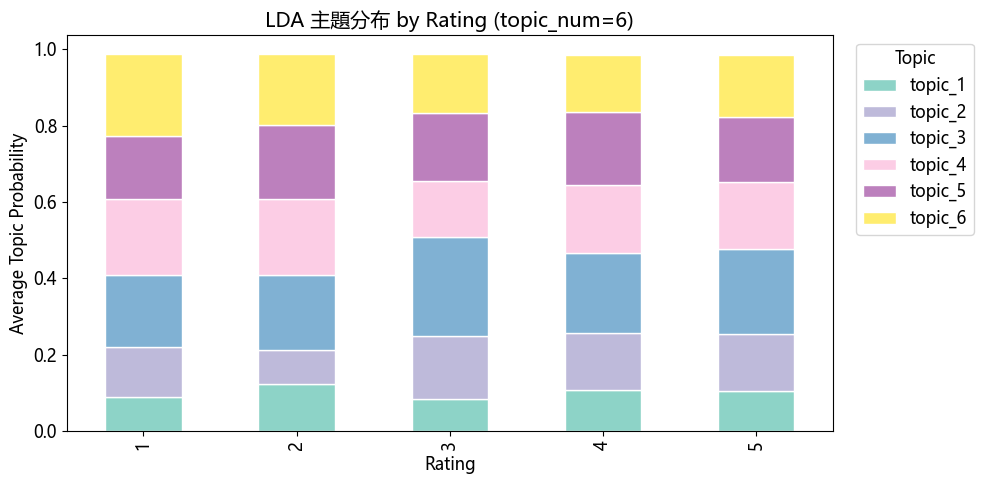

In [83]:
if gensim_available:
    # 各評論的主題分布
    topics_doc = best_lda.get_document_topics(corpus)
    m_theta = corpus2csc(topics_doc).T.toarray()
    theta = pd.DataFrame(m_theta, columns=[f'topic_{i+1}' for i in range(BEST_TOPIC_NUM)])
    
    df_lda_result = df_lda.iloc[:len(theta)].reset_index(drop=True)
    df_lda_result = pd.concat([df_lda_result[['rating']].reset_index(drop=True), theta], axis=1)
    
    # 各評分組的主題分布
    topic_by_rating = (
        df_lda_result.groupby('rating')[[f'topic_{i+1}' for i in range(BEST_TOPIC_NUM)]]
        .mean()
    )
    
    fig, ax = plt.subplots(figsize=(10, 5))
    topic_by_rating.plot.bar(ax=ax, stacked=True, colormap='Set3', edgecolor='white')
    ax.set_xlabel('Rating')
    ax.set_ylabel('Average Topic Probability')
    ax.set_title(f'LDA 主題分布 by Rating (topic_num={BEST_TOPIC_NUM})')
    ax.legend(title='Topic', bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

In [84]:
# pyLDAvis 互動式視覺化
try:
    import pyLDAvis
    import pyLDAvis.gensim_models as gensimvis
    from IPython.display import display, HTML
    if gensim_available:
        lda_display = gensimvis.prepare(best_lda, corpus, dictionary, sort_topics=False)
        html_str = pyLDAvis.prepared_data_to_html(lda_display)
        display(HTML(html_str))
except ImportError:
    print('請安裝 pyLDAvis: pip install pyLDAvis')
    if gensim_available:
        # 靜態替代：各主題前10詞的長條圖
        fig, axes = plt.subplots(1, BEST_TOPIC_NUM, figsize=(18, 5))
        colors = ['tab:blue','tab:orange','tab:green','tab:red','tab:purple']
        for i, ax in enumerate(axes[:BEST_TOPIC_NUM]):
            top = best_lda.show_topic(i, topn=10)
            words, probs = zip(*top)
            ax.barh(list(words)[::-1], list(probs)[::-1], color=colors[i % len(colors)])
            ax.set_title(f'Topic {i+1}')
            ax.set_xlabel('Probability')
        plt.suptitle('LDA 各主題詞分布', fontsize=14, y=1.01)
        plt.tight_layout()
        plt.show()


---
## 語意嵌入（Sentence Embeddings）

- 使用 **sentence-transformers** 將評論轉換為語義向量
- **t-SNE** 降維視覺化（2D / 3D）
- **K-means** 分群，觀察分群與評分的關聯

> 注意：需要安裝 `pip install sentence-transformers`

In [85]:
try:
    from sentence_transformers import SentenceTransformer
    from sklearn.manifold import TSNE
    from sklearn.cluster import KMeans
    st_available = True
except ImportError:
    print('請安裝 sentence-transformers: pip install sentence-transformers')
    st_available = False

if st_available:
    # 取樣 500 筆評論（避免記憶體不足）
    EMBED_N = 500
    df_embed = df_sample.sample(n=EMBED_N, random_state=42).reset_index(drop=True)
    
    # 使用輕量模型（all-MiniLM-L6-v2）
    print('載入 sentence-transformers 模型...')
    embed_model = SentenceTransformer('all-MiniLM-L6-v2')
    
    print('生成 Sentence Embeddings...')
    embeddings = embed_model.encode(
        df_embed['review'].tolist(),
        show_progress_bar=True,
        batch_size=32
    )
    print(f'Embedding shape: {embeddings.shape}')

載入 sentence-transformers 模型...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

生成 Sentence Embeddings...


Batches:   0%|          | 0/16 [00:00<?, ?it/s]

Embedding shape: (500, 384)


t-SNE 降維中...


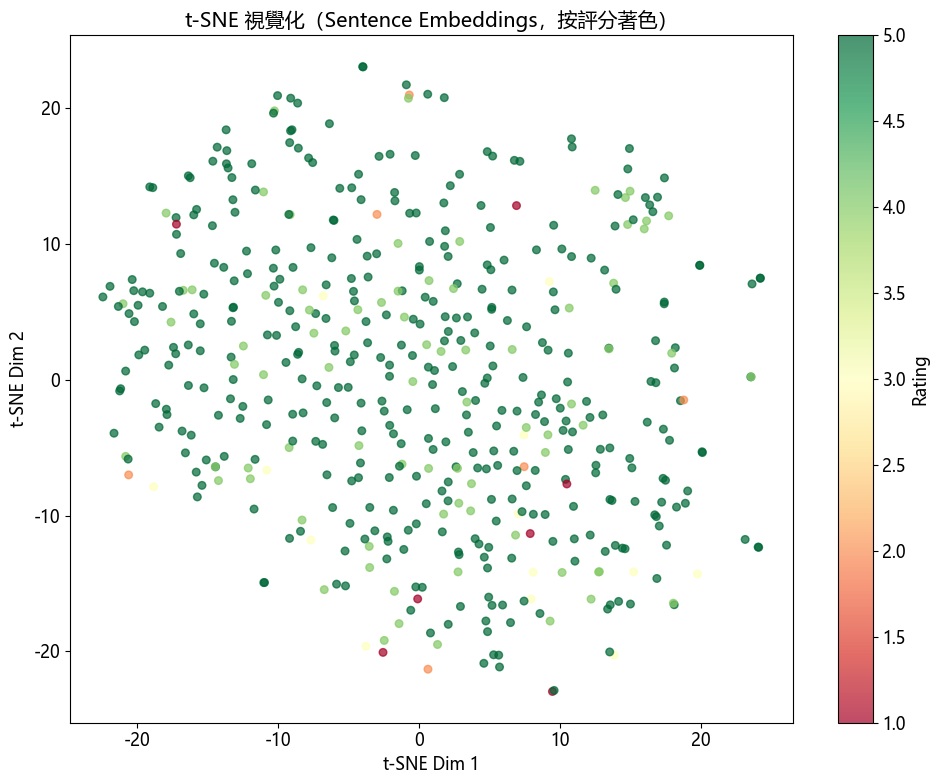

In [86]:
if st_available:
    # t-SNE 降維（從 384 維 → 2 維）
    print('t-SNE 降維中...')
    tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
    embeddings_2d = tsne.fit_transform(embeddings)
    
    df_embed['x'] = embeddings_2d[:, 0]
    df_embed['y'] = embeddings_2d[:, 1]
    
    # 以評分著色
    fig, ax = plt.subplots(figsize=(10, 8))
    scatter = ax.scatter(
        df_embed['x'], df_embed['y'],
        c=df_embed['rating'],
        cmap='RdYlGn',
        alpha=0.7,
        s=30
    )
    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_label('Rating')
    ax.set_title('t-SNE 視覺化（Sentence Embeddings，按評分著色）')
    ax.set_xlabel('t-SNE Dim 1')
    ax.set_ylabel('t-SNE Dim 2')
    plt.tight_layout()
    plt.show()

In [87]:
if st_available:
    # t-SNE 三維降維（從 384 維 → 3 維）
    import plotly.express as px
    print('t-SNE 3D 降維中...')
    tsne_3d = TSNE(n_components=3, random_state=42, perplexity=30, max_iter=1000)
    embeddings_3d = tsne_3d.fit_transform(embeddings)

    df_embed['x3'] = embeddings_3d[:, 0]
    df_embed['y3'] = embeddings_3d[:, 1]
    df_embed['z3'] = embeddings_3d[:, 2]

    fig_3d = px.scatter_3d(
        df_embed, x='x3', y='y3', z='z3',
        color='rating',
        color_continuous_scale='RdYlGn',
        opacity=0.75,
        size_max=6,
        title='t-SNE 3D 視覺化（Sentence Embeddings，按評分著色）',
        labels={'x3': 't-SNE Dim 1', 'y3': 't-SNE Dim 2', 'z3': 't-SNE Dim 3'}
    )
    fig_3d.update_traces(marker=dict(size=4))
    fig_3d.update_layout(
        width=800, height=700,
        scene=dict(
            xaxis_title='t-SNE Dim 1',
            yaxis_title='t-SNE Dim 2',
            zaxis_title='t-SNE Dim 3'
        )
    )
    fig_3d.show()


t-SNE 3D 降維中...


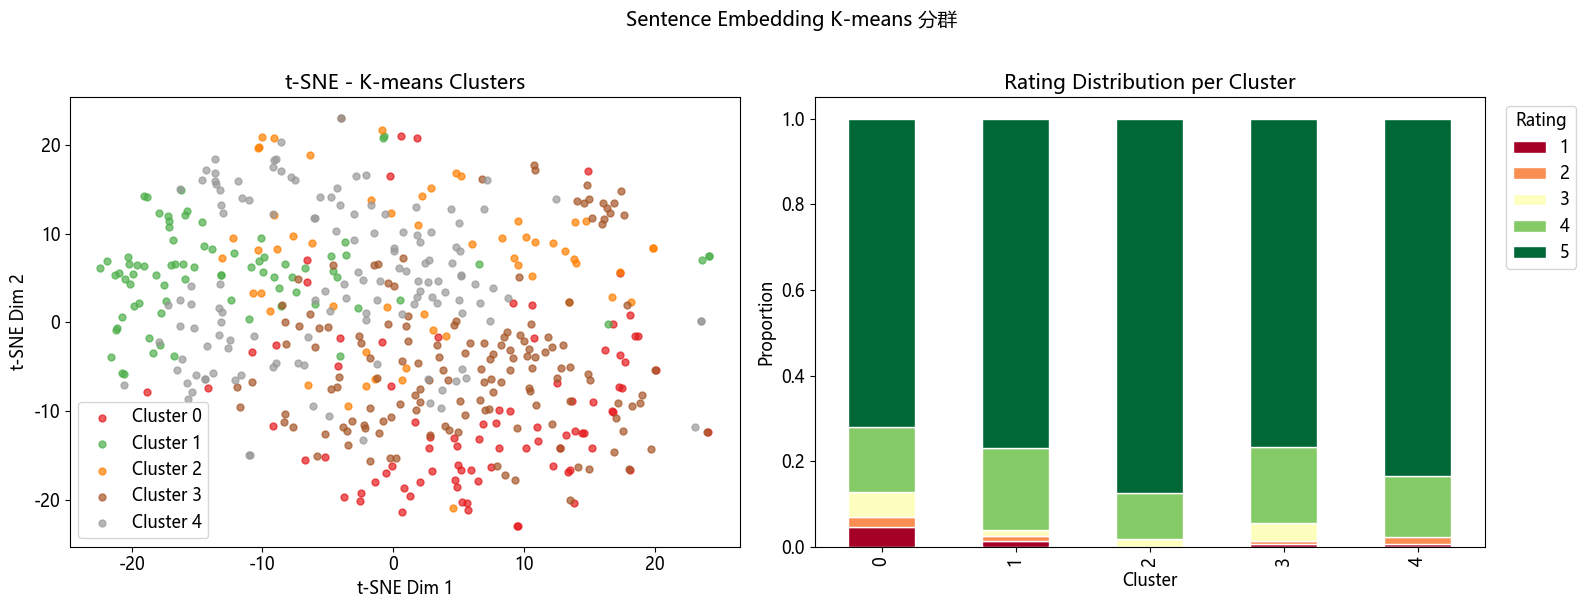

各群的平均評分：
cluster
0    4.48
1    4.69
2    4.86
3    4.69
4    4.78
Name: rating, dtype: float64


In [88]:
if st_available:
    # K-means 分群（5 群）
    N_CLUSTERS = 5
    kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10)
    df_embed['cluster'] = kmeans.fit_predict(embeddings)
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # 分群散點圖
    cluster_colors = plt.cm.Set1(np.linspace(0, 1, N_CLUSTERS))
    for i in range(N_CLUSTERS):
        mask = df_embed['cluster'] == i
        axes[0].scatter(df_embed[mask]['x'], df_embed[mask]['y'],
                        alpha=0.7, s=25, label=f'Cluster {i}', color=cluster_colors[i])
    axes[0].legend()
    axes[0].set_title('t-SNE - K-means Clusters')
    axes[0].set_xlabel('t-SNE Dim 1')
    axes[0].set_ylabel('t-SNE Dim 2')
    
    # 各 cluster 的評分分布
    cluster_rating = (
        df_embed.groupby(['cluster', 'rating'])
        .size()
        .reset_index(name='count')
    )
    cluster_rating_pivot = cluster_rating.pivot(index='cluster', columns='rating', values='count').fillna(0)
    cluster_rating_pivot.div(cluster_rating_pivot.sum(axis=1), axis=0).plot.bar(
        ax=axes[1], stacked=True, colormap='RdYlGn', edgecolor='white'
    )
    axes[1].set_xlabel('Cluster')
    axes[1].set_ylabel('Proportion')
    axes[1].set_title('Rating Distribution per Cluster')
    axes[1].legend(title='Rating', bbox_to_anchor=(1.02, 1))
    
    plt.suptitle('Sentence Embedding K-means 分群', fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()
    
    # 各群的平均評分
    print('各群的平均評分：')
    print(df_embed.groupby('cluster')['rating'].mean().round(2))

In [89]:
if st_available:
    # 找出最相似的評論（以 Cosine Similarity 搜尋）
    query = 'This recipe is absolutely delicious and easy to make!'
    query_embedding = embed_model.encode([query])
    
    sims = cosine_similarity(query_embedding, embeddings)[0]
    top_sim_idx = sims.argsort()[-5:][::-1]
    
    print(f'查詢句："{query}"\n')
    print('最相似的前5筆評論：')
    for i, idx in enumerate(top_sim_idx):
        print(f'\n{i+1}. 相似度: {sims[idx]:.4f} | Rating: {df_embed["rating"][idx]}')
        print(f'   "{df_embed["review"][idx][:120]}"')

查詢句："This recipe is absolutely delicious and easy to make!"

最相似的前5筆評論：

1. 相似度: 0.7924 | Rating: 4
   "I love recipes that are so deceptively simple and turn out so well! This is a great recipe and one I will use again. Tha"

2. 相似度: 0.7887 | Rating: 5
   "Tasted very good.  Very easy to make. Thanks for this recipe. "

3. 相似度: 0.7873 | Rating: 5
   "Wow!!  I didn't really know what to expect with this one, but it was wonderful.  TRY THIS RECIPE!!!  You won't regret it"

4. 相似度: 0.7852 | Rating: 5
   "So simple, yet so delicious. A great side dish that I will surely make again.  Thank you for posting this recipe."

5. 相似度: 0.7792 | Rating: 5
   "I can't wait to make it again! This was a big hit at my house and soooo easy!  If you're debating because it's just 5 in"


---
## 語意主題模型（BERTopic）

使用 **BERTopic** 結合 BERT 語義向量進行主題模型分析，相比 LDA 能更好地捕捉語義關係。

> 注意：需要安裝 `pip install bertopic hdbscan`

In [90]:
try:
    from bertopic import BERTopic
    from hdbscan import HDBSCAN
    bertopic_available = True
except ImportError:
    print('請安裝 BERTopic: pip install bertopic hdbscan')
    bertopic_available = False

if bertopic_available:
    BERT_N = 1000
    df_bert = df_sample.sample(n=BERT_N, random_state=42).reset_index(drop=True)
    docs_bert = df_bert['review'].tolist()
    
    # 建立 BERTopic 模型
    topic_model_bert = BERTopic(
        embedding_model='all-MiniLM-L6-v2',
        hdbscan_model=HDBSCAN(min_cluster_size=15, min_samples=5),
        vectorizer_model=CountVectorizer(stop_words='english', max_features=1000),
        verbose=False
    )
    
    topics_bert, probs_bert = topic_model_bert.fit_transform(docs_bert)
    topic_info_bert = topic_model_bert.get_topic_info()
    
    print(f'發現主題數（不含雜訊）: {len(topic_info_bert) - 1}')
    print(f'雜訊（-1）文件數: {(np.array(topics_bert) == -1).sum()}')
    topic_info_bert.head(10)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

發現主題數（不含雜訊）: 20
雜訊（-1）文件數: 356


BERTopic 各主題關鍵字：

Topic 0 (n=67): rolls, recipe, good, make, great, time, thanks, easy
Topic 1 (n=57): bread, flour, loaf, wheat, dough, great, good, make
Topic 2 (n=52): recipe, drink, make, love, thanks, great, big, mint
Topic 3 (n=51): pork, steak, beef, sauce, meat, meatballs, gravy, used
Topic 4 (n=49): good, chili, sauce, pepper, rice, dish, used, little
Topic 5 (n=46): loved, stars, yummy, thanks, good, enjoyed, really, dish
Topic 6 (n=41): cookies, cookie, butter, half, bars, sugar, recipe, chocolate
Topic 7 (n=38): chicken, recipe, breasts, thanks, skin, moist, used, crumbs


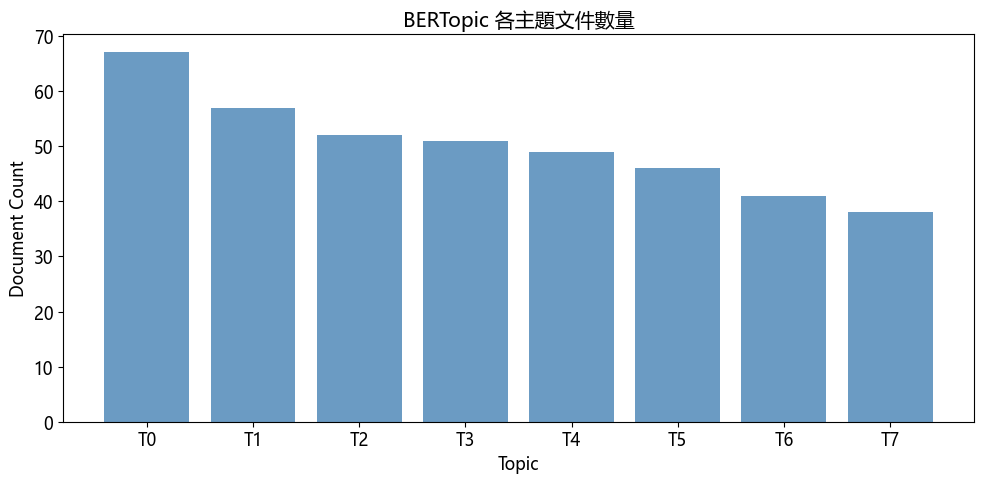

In [91]:
if bertopic_available:
    # 顯示各主題關鍵字
    valid_topics = topic_info_bert[topic_info_bert['Topic'] != -1].head(8)
    print('BERTopic 各主題關鍵字：\n')
    for _, row in valid_topics.iterrows():
        tid = row['Topic']
        keywords = topic_model_bert.get_topic(tid)
        kw_str = ', '.join([w for w, _ in keywords[:8]])
        print(f'Topic {tid} (n={row["Count"]}): {kw_str}')
    
    # 靜態視覺化：主題大小長條圖
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar(range(len(valid_topics)),
           valid_topics['Count'].values,
           color='steelblue', alpha=0.8)
    ax.set_xticks(range(len(valid_topics)))
    ax.set_xticklabels([f'T{t}' for t in valid_topics['Topic'].values])
    ax.set_xlabel('Topic')
    ax.set_ylabel('Document Count')
    ax.set_title('BERTopic 各主題文件數量')
    plt.tight_layout()
    plt.show()

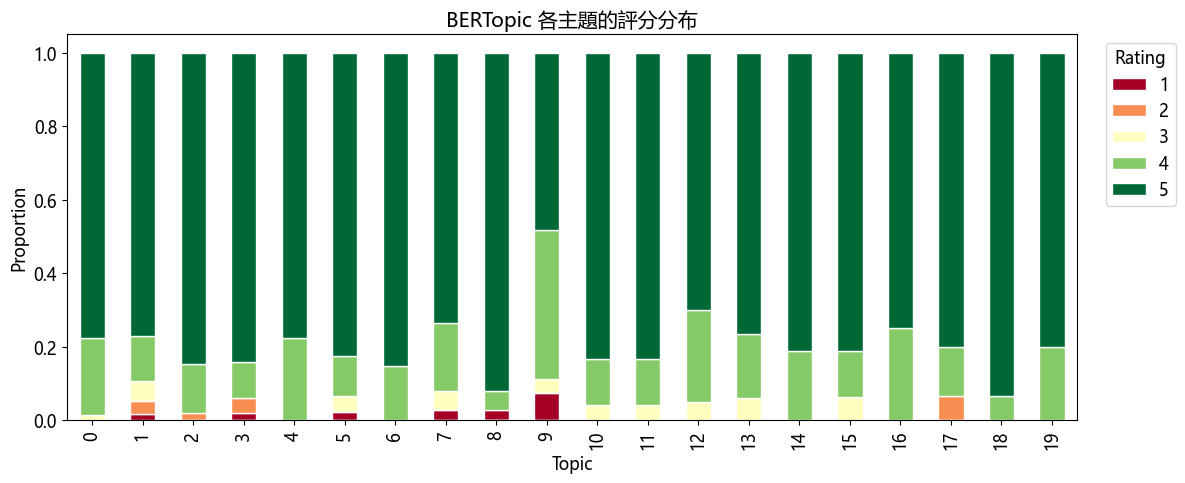

In [92]:
if bertopic_available:
    # 各主題的評分分布
    df_bert['topic'] = topics_bert
    df_bert_valid = df_bert[df_bert['topic'] != -1].copy()
    
    if len(df_bert_valid) > 0:
        topic_rating = (
            df_bert_valid.groupby(['topic', 'rating'])
            .size()
            .reset_index(name='count')
        )
        topic_rating_pivot = (
            topic_rating.pivot(index='topic', columns='rating', values='count')
            .fillna(0)
        )
        topic_rating_norm = topic_rating_pivot.div(topic_rating_pivot.sum(axis=1), axis=0)
        
        fig, ax = plt.subplots(figsize=(12, 5))
        topic_rating_norm.plot.bar(ax=ax, stacked=True, colormap='RdYlGn', edgecolor='white')
        ax.set_xlabel('Topic')
        ax.set_ylabel('Proportion')
        ax.set_title('BERTopic 各主題的評分分布')
        ax.legend(title='Rating', bbox_to_anchor=(1.02, 1))
        plt.tight_layout()
        plt.show()

In [97]:
if bertopic_available:
    import anthropic
    
    client = anthropic.Anthropic()  # 需設定 Cladue API key
    
    def label_topic_with_claude(keywords, sample_reviews):
        prompt = f"""你是一個主題分析專家。以下是一組從食譜評論中萃取出的關鍵詞，以及幾則該主題的代表性評論。

                關鍵詞：{', '.join(keywords)}
                
                代表性評論：
                {chr(10).join(f'- {r}' for r in sample_reviews[:5])}
                
                請給這個主題：
                1. 一個簡短的中文標籤（5-8字）
                2. 一句話說明這個主題在講什麼（中文）
                
                請用以下格式回答，不要有其他內容：
                標籤：xxx
                說明：xxx
                """
        message = client.messages.create(
            model="claude-sonnet-4-6",
            max_tokens=400,
            messages=[{"role": "user", "content": prompt}]
        )
        return message.content[0].text
    
    print('使用 Claude 為各主題自動命名與解釋：\n')
    topic_labels = {}  # 存起來，後面圖表可以用
    
    for _, row in valid_topics.iterrows():
        tid = row['Topic']
        keywords = [w for w, _ in topic_model_bert.get_topic(tid)[:8]]
        sample_docs = topic_model_bert.get_representative_docs(tid)
        
        result = label_topic_with_claude(keywords, sample_docs)
        topic_labels[tid] = result
        
        print(f'--- Topic {tid} (n={row["Count"]}) ---')
        print(f'關鍵字：{", ".join(keywords)}')
        print(result)
        print()

使用 Claude 為各主題自動命名與解釋：

--- Topic 0 (n=67) ---
關鍵字：rolls, recipe, good, make, great, time, thanks, easy
標籤：簡易食譜好評分享
說明：評論者稱讚食譜簡單易做且美味，並感謝分享者提供如此方便又獲得家人喜愛的料理方法。

--- Topic 1 (n=57) ---
關鍵字：bread, flour, loaf, wheat, dough, great, good, make
標籤：自製麵包的製作心得
說明：此主題圍繞著讀者親手製作各式麵包的經驗，包含麵粉種類選擇、麵團處理技巧及烘焙成果分享。

--- Topic 2 (n=52) ---
關鍵字：recipe, drink, make, love, thanks, great, big, mint
標籤：薄荷飲品食譜的愛恨評價
說明：讀者分享製作薄荷相關飲品或甜點食譜的經驗，表達對食譜的喜愛或失敗的強烈感受。

--- Topic 3 (n=51) ---
關鍵字：pork, steak, beef, sauce, meat, meatballs, gravy, used
標籤：肉類料理與醬汁風味
說明：此主題圍繞豬肉、牛肉等肉類料理的烹飪心得，著重分享肉質軟嫩程度與肉汁醬料的調味技巧。

--- Topic 4 (n=49) ---
關鍵字：good, chili, sauce, pepper, rice, dish, used, little
標籤：調味料與米飯料理變化
說明：評論者分享在烹飪過程中如何調整辣椒、醬料、胡椒等調味料，並針對米飯料理進行個人化改良的心得。

--- Topic 5 (n=46) ---
關鍵字：loved, stars, yummy, thanks, good, enjoyed, really, dish
標籤：美味好評與感謝讚揚
說明：評論者對食譜給予高度正面評價，表達喜愛之情並感謝食譜分享者。

--- Topic 6 (n=41) ---
關鍵字：cookies, cookie, butter, half, bars, sugar, recipe, chocolate
標籤：餅乾與點心的烘焙調整
說明：評論者分享製作餅乾、穀物棒等烘焙點心的經驗，並討論對食譜的各種替換與份量調

---
## 詞彙網路圖（Bigram Network）

以 **NetworkX** 建立詞彙共現網路（Word Co-occurrence Network），節點為詞彙，邊的粗細對應 Bigram 出現頻率，節點大小依度中心性（Degree Centrality）決定。

In [98]:
# 14.1 建立 Bigram 網路
top_bigrams_net = bigram_freq.most_common(40)
bigram_dict_net = {k: v for k, v in top_bigrams_net}

G = nx.Graph()
for (w1, w2), count in bigram_dict_net.items():
    G.add_edge(w1, w2, weight=count)

print(f'節點數: {G.number_of_nodes()}')
print(f'邊數:   {G.number_of_edges()}')

# 邊的寬度與節點大小
weights = [G[u][v]['weight'] * 0.04 for u, v in G.edges()]
degree_centrality = nx.degree_centrality(G)
node_sizes = [degree_centrality[n] * 3000 + 100 for n in G.nodes()]

節點數: 48
邊數:   39


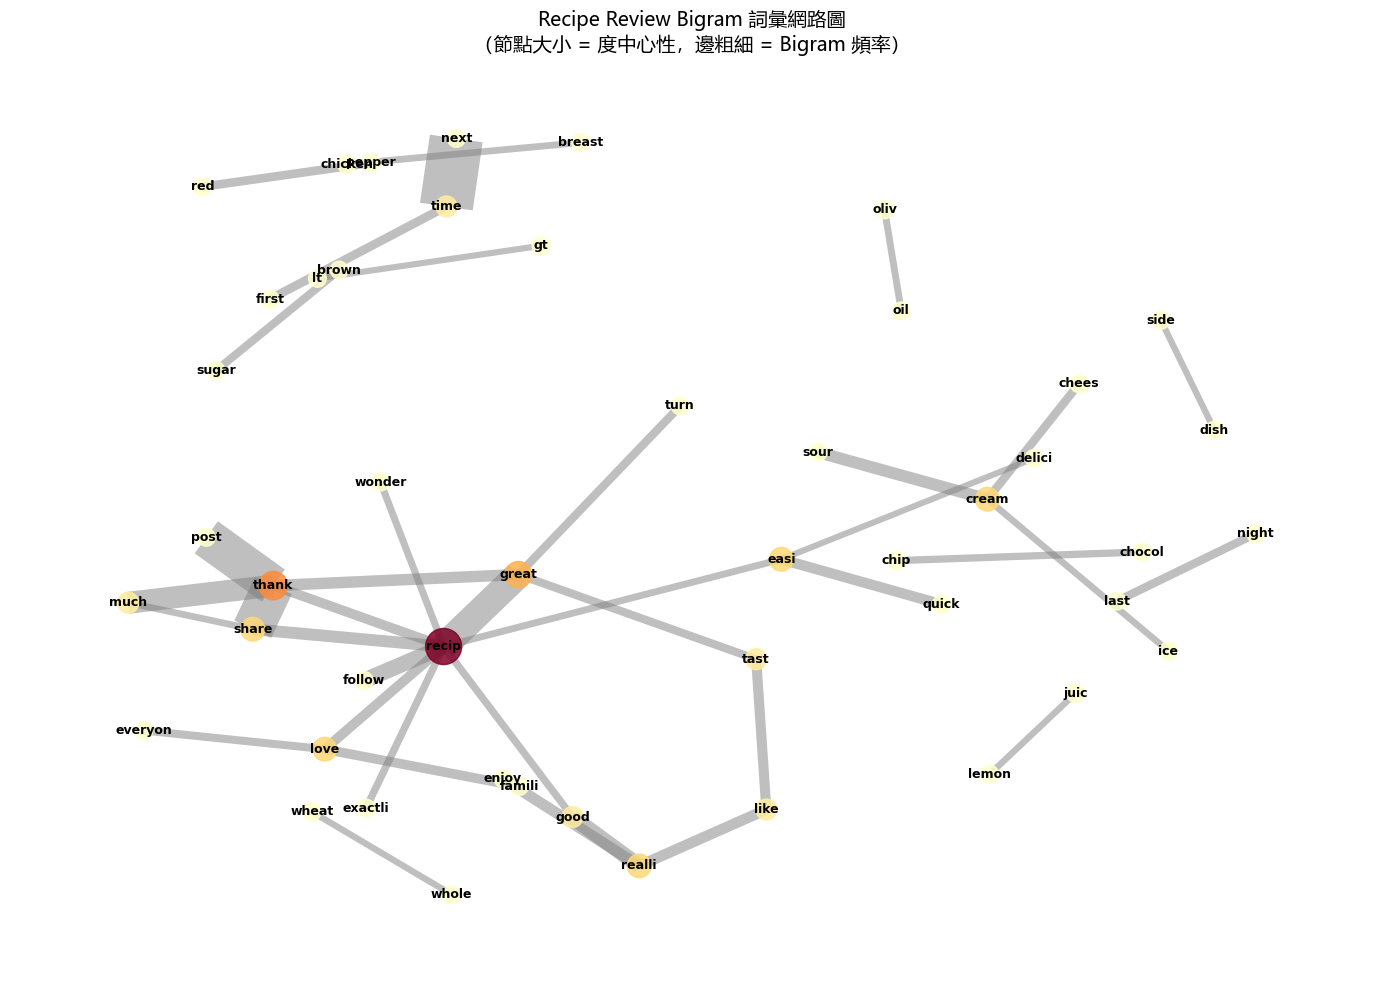

In [99]:
# 14.2 網路圖視覺化
fig, ax = plt.subplots(figsize=(14, 10))
pos = nx.spring_layout(G, k=2.5, seed=42)

# 畫邊
nx.draw_networkx_edges(
    G, pos, width=weights, alpha=0.5, edge_color='gray', ax=ax
)

# 畫節點（顏色依度中心性深淺）
nx.draw_networkx_nodes(
    G, pos, node_size=node_sizes,
    node_color=list(degree_centrality.values()),
    cmap='YlOrRd', alpha=0.85, ax=ax
)

# 畫標籤
nx.draw_networkx_labels(
    G, pos, font_size=9, font_weight='bold', ax=ax
)

ax.set_title('Recipe Review Bigram 詞彙網路圖\n（節點大小 = 度中心性，邊粗細 = Bigram 頻率）',
             fontsize=14)
ax.axis('off')
plt.tight_layout()
plt.show()

In [100]:
# 14.3 網路中心性分析
print('度中心性（Degree Centrality）最高的詞：')
top_central = sorted(degree_centrality.items(), key=lambda x: x[1], reverse=True)[:12]
for word, c in top_central:
    print(f'  {word:<15} {c:.4f}')

print('\n中介中心性（Betweenness Centrality）：')
between_c = nx.betweenness_centrality(G)
top_between = sorted(between_c.items(), key=lambda x: x[1], reverse=True)[:8]
for word, c in top_between:
    print(f'  {word:<15} {c:.4f}')

度中心性（Degree Centrality）最高的詞：
  recip           0.1915
  thank           0.1064
  great           0.0851
  share           0.0638
  realli          0.0638
  cream           0.0638
  easi            0.0638
  love            0.0638
  time            0.0426
  much            0.0426
  good            0.0426
  like            0.0426

中介中心性（Betweenness Centrality）：
  recip           0.1366
  great           0.0390
  easi            0.0342
  love            0.0342
  good            0.0327
  thank           0.0290
  realli          0.0239
  tast            0.0117


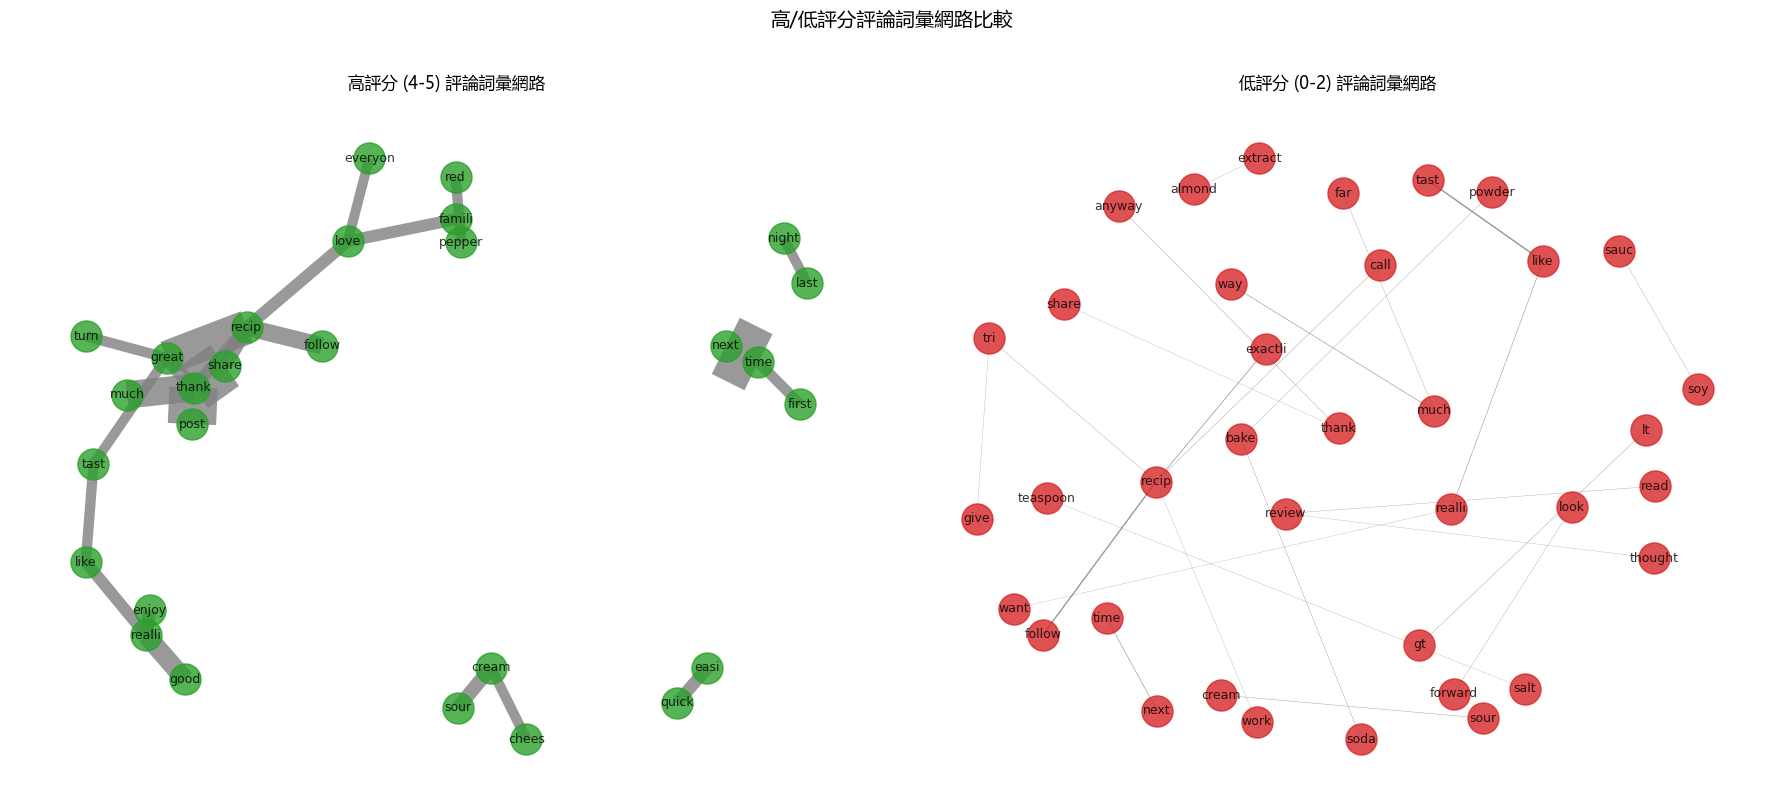

In [101]:
# 14.4 高/低評分評論的 Bigram 網路比較
def get_rating_bigrams(df, rating_filter, min_count=5, top_n=25):
    sub = df[df['rating'].isin(rating_filter)]
    all_bg = []
    for rev in sub['review']:
        all_bg.extend(get_bigrams(rev))
    freq = FreqDist(all_bg)
    return {k: v for k, v in freq.most_common(top_n) if v >= min_count}

bg_high = get_rating_bigrams(df_sample, [4, 5], min_count=5)
bg_low  = get_rating_bigrams(df_sample, [0, 1, 2], min_count=3)

G_high = nx.Graph()
for (w1, w2), c in bg_high.items():
    G_high.add_edge(w1, w2, weight=c)

G_low = nx.Graph()
for (w1, w2), c in bg_low.items():
    G_low.add_edge(w1, w2, weight=c)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

for ax, G_sub, title, node_color in [
    (axes[0], G_high, '高評分 (4-5) 評論詞彙網路', 'tab:green'),
    (axes[1], G_low,  '低評分 (0-2) 評論詞彙網路', 'tab:red')
]:
    if G_sub.number_of_nodes() == 0:
        ax.text(0.5, 0.5, '資料不足', ha='center', va='center')
        ax.set_title(title)
        continue
    pos = nx.spring_layout(G_sub, k=2, seed=42)
    w = [G_sub[u][v]['weight'] * 0.05 for u, v in G_sub.edges()]
    nx.draw_networkx(G_sub, pos, ax=ax, font_size=9, width=w,
                     edge_color='grey', node_color=node_color,
                     node_size=500, alpha=0.8)
    ax.set_title(title, fontsize=12)
    ax.axis('off')

plt.suptitle('高/低評分評論詞彙網路比較', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

---
## 分析結果

- **資料前處理**：最常出現 `love`、`great`、`good`、`like` 等正向詞彙
- **情緒分析**：評分越高，正向情緒詞比例越高；負向詞彙集中於低評分
- **文本特徵提取**：bigram（TF-IDF）結果以社交禮貌用語為主（如「next time」「thank share」），食材／口感詞彙較少（如「sour cream」「tast like」），顯示評論偏重情感互動而非食物細節
- **文件分類**：Logistic Regression 表現最佳（F1 ≈ 0.97），「great」→ positive，「bad」→ negative
- **主題模型**：LDA（6主題）部分呈現料理類型差異，如 Topic 1 偏向烘焙甜點（cake, sugar, cream, chocolate），Topic 4 偏向醬料調味（sauce, pepper, chicken）；但多數主題仍混雜大量通用評價詞（recip, good, great, love），主題間區隔不夠清晰
- **語意嵌入**：t-SNE 視覺化顯示高低評分評論形成不同群集
- **語意主題模型**：BERTopic 找到的主題語義連貫性明顯優於 LDA，能清楚區分具體料理類型（如 Topic 1 麵包烘焙、Topic 3 肉類料理、Topic 2 薄荷飲品），相較 LDA 主題普遍被「recipe, good, great」等通用詞主導，BERTopic 的分群更貼近食譜實際內容
- **詞彙網路圖**：`recip`、`thank`、`great` 為度中心性最高的核心詞彙


## YT網址

https://www.youtube.com/watch?v=EhOJEhjqdNY